# Forecast Data Inspection and Ingestion

This notebook inspects the new forecasting archive data for 5 catchments in the Harz region.
Data sources: Radklim, Hostrada, ICON-D2 (deterministic & ensemble).

**Goals:**
1. Detect file formats and structure.
2. Implement robust data loaders.
3. Perform quality checks and visualization.
4. Verify forecast horizons and lead times.

In [2]:
import os
import glob
import re
from pathlib import Path
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# Set output display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [3]:
# Project Configuration
BASE_DIR = Path("../../data/harz/icond2").resolve()
print(f"Data Directory: {BASE_DIR}")

TIMEZONE = "UTC"

Data Directory: /home/sngrj0hn/GitHub/neuralhydrology/neuralhydrology/data/harz/icond2


In [4]:
def get_obs(catchment, start=None, end=None, vars=None):
    """
    Load observation data for a specific catchment.
    """
    pattern = f"*timeseries*gregor_{catchment}.csv"
    files = list(BASE_DIR.rglob(pattern))
    if not files:
        raise FileNotFoundError(f"No observation file found for catchment {catchment}")
    
    file_path = files[0]
    df = pd.read_csv(file_path)
    
    # Process time (CSV had UTC offset)
    df['time'] = pd.to_datetime(df['time'], utc=True)
    df = df.set_index('time')
    
    if start:
        df = df[df.index >= pd.to_datetime(start, utc=True)]
    if end:
        df = df[df.index <= pd.to_datetime(end, utc=True)]
        
    if vars:
        available_vars = [v for v in vars if v in df.columns]
        df = df[available_vars]
        
    return df

def get_fcst_det(catchment, init_start=None, init_end=None, leads=None, vars=None):
    """
    Load deterministic forecast data.
    """
    pattern = f"*deterministic*gregor_{catchment}.nc"
    files = list(BASE_DIR.rglob(pattern))
    if not files:
        raise FileNotFoundError(f"No deterministic forecast file found for catchment {catchment}")
    
    # Avoid FutureWarning
    ds = xr.open_dataset(files[0], decode_timedelta=False)
    
    if init_start:
        ts_start = pd.to_datetime(init_start)
        if ts_start.tz is not None:
             ts_start = ts_start.tz_localize(None)
        ds = ds.sel(init_time=slice(ts_start, None))
        
    if init_end:
        ts_end = pd.to_datetime(init_end)
        if ts_end.tz is not None:
             ts_end = ts_end.tz_localize(None)
        ds = ds.sel(init_time=slice(None, ts_end))
        
    if leads is not None:
        ds = ds.sel(lead_time=leads)
        
    if vars:
        ds = ds[vars]
        
    return ds

def get_fcst_ens_precip(catchment, init_start=None, init_end=None, leads=None):
    """
    Load ensemble precipitation forecast.
    """
    pattern = f"*ensemble*gregor_{catchment}.nc"
    files = list(BASE_DIR.rglob(pattern))
    if not files:
        raise FileNotFoundError(f"No ensemble file found for catchment {catchment}")
        
    # Avoid FutureWarning
    ds = xr.open_dataset(files[0], decode_timedelta=False)
    
    if init_start:
        ts_start = pd.to_datetime(init_start)
        if ts_start.tz is not None:
             ts_start = ts_start.tz_localize(None)
        ds = ds.sel(init_time=slice(ts_start, None))
        
    if init_end:
        ts_end = pd.to_datetime(init_end)
        if ts_end.tz is not None:
             ts_end = ts_end.tz_localize(None)
        ds = ds.sel(init_time=slice(None, ts_end))
        
    if leads is not None:
        ds = ds.sel(lead_time=leads)
        
    return ds

Generating variable overview for: ecker

=== DETERMINISTIC VARIABLES ===
Coordinates: ['gauge_id', 'init_time', 'lead_time']
Variables: ['precipitation_mean', 'precipitation_min', 'precipitation_max', 'precipitation_stdev', 'temperature_mean', 'air_pressure_sea_level_mean', 'snow_depth_water_eq_mean', 'global_radiation_mean', 'wind_speed_eastward_mean', 'wind_speed_northward_mean', 'wind_speed_mean', 'wind_direction_mean']

=== ENSEMBLE VARIABLES ===
Coordinates: ['gauge_id', 'init_time', 'ensemble_member', 'lead_time']
Variables: ['precipitation_mean', 'precipitation_min', 'precipitation_max', 'precipitation_stdev']


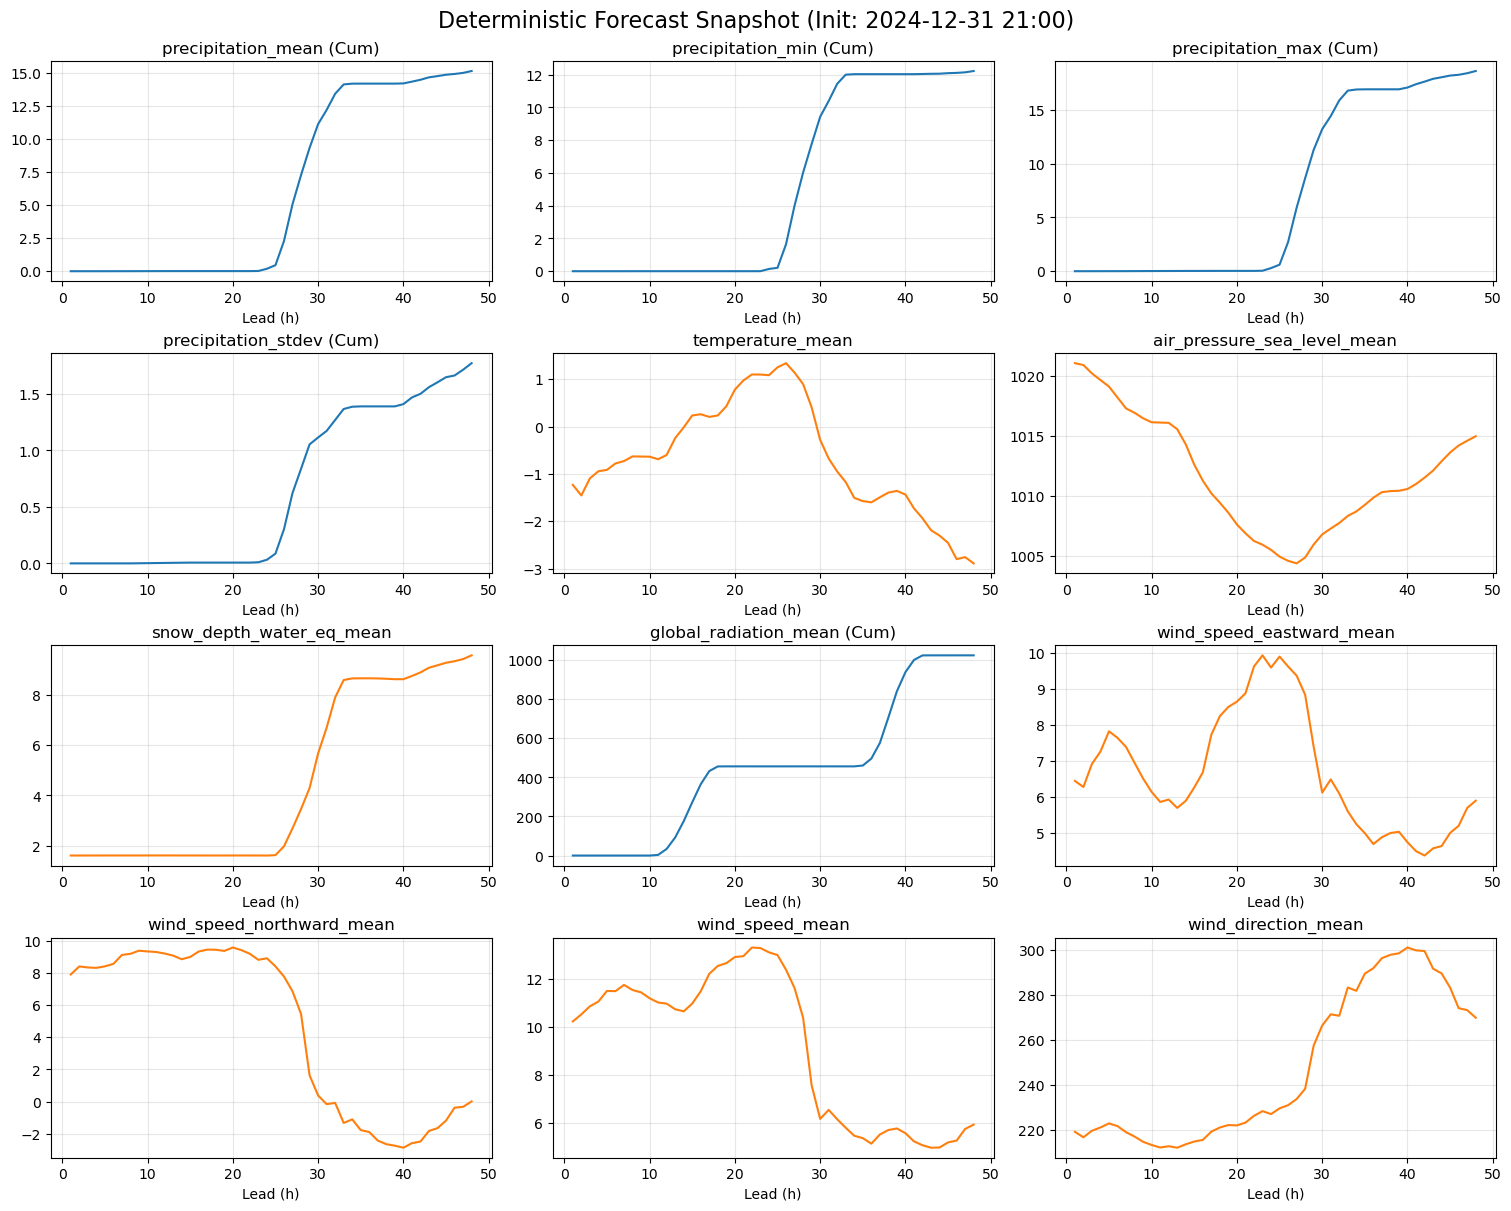

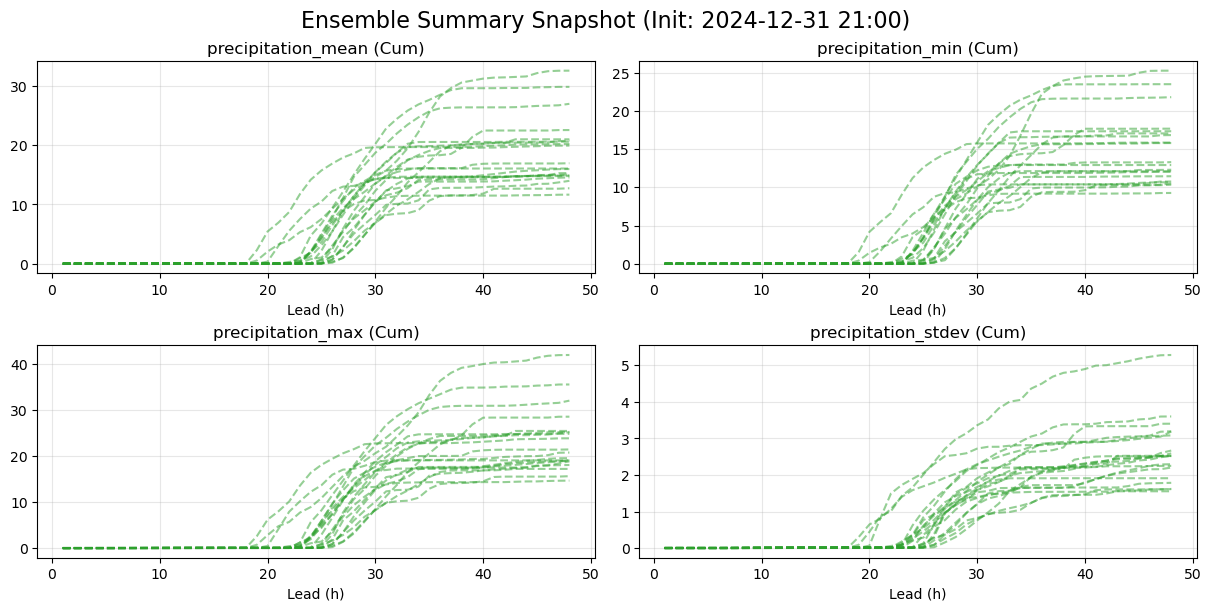

In [5]:
# 3. Variable Inventory & Visual Snapshots
# Define target catchment manually since discovery is removed
target_cid = "ecker" 
print(f"Generating variable overview for: {target_cid}")

try:
    ds_det = get_fcst_det(target_cid)
    ds_ens = get_fcst_ens_precip(target_cid)
    
    print("\n=== DETERMINISTIC VARIABLES ===")
    print(f"Coordinates: {list(ds_det.coords)}")
    print(f"Variables: {list(ds_det.data_vars)}")
    
    print("\n=== ENSEMBLE VARIABLES ===")
    print(f"Coordinates: {list(ds_ens.coords)}")
    print(f"Variables: {list(ds_ens.data_vars)}")

    # ---------------------------------------------------------
    # A. Deterministic Snapshot
    # ---------------------------------------------------------
    vis_vars_det = list(ds_det.data_vars)
    if vis_vars_det:
        n_vars = len(vis_vars_det)
        cols = 3
        rows = (n_vars // cols) + (1 if n_vars % cols > 0 else 0)
        
        # Determine last available initialization time
        last_init_time = ds_det.init_time.values[-1]
        
        # Select and squeeze, being careful with coordinates
        sample_fcst_det = ds_det.sel(init_time=last_init_time)
        if 'gauge_id' in sample_fcst_det.coords:
            sample_fcst_det = sample_fcst_det.drop_vars('gauge_id')
        sample_fcst_det = sample_fcst_det.squeeze()

        # Handle lead times for deterministic
        if pd.api.types.is_timedelta64_dtype(sample_fcst_det.lead_time):
             lead_times_det = sample_fcst_det.lead_time.values.astype('timedelta64[h]').astype(int)
        else:
             # Fallback if lead_time wasn't decoded or is just integers
             lead_times_det = sample_fcst_det.lead_time.values

        fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows), constrained_layout=True)
        fig.suptitle(f'Deterministic Forecast Snapshot (Init: {pd.to_datetime(last_init_time).strftime("%Y-%m-%d %H:%M")})', fontsize=16)
        axes = axes.flatten()
        
        for i, var in enumerate(vis_vars_det):
            ax = axes[i]
            data = sample_fcst_det[var].values
            
            if 'precip' in var.lower() or 'radiation' in var.lower():
                 ax.plot(lead_times_det, np.cumsum(data), color='tab:blue')
                 ax.set_title(f"{var} (Cum)")
            else:
                 ax.plot(lead_times_det, data, color='tab:orange')
                 ax.set_title(var)
            
            ax.set_xlabel('Lead (h)')
            ax.grid(True, alpha=0.3)
            
        for j in range(i+1, len(axes)):
            axes[j].axis('off')
            
        plt.show()
    else:
        print("No deterministic variables found to plot.")

    # ---------------------------------------------------------
    # B. Ensemble Snapshot
    # ---------------------------------------------------------
    vis_vars_ens = list(ds_ens.data_vars)
    if vis_vars_ens:
        n_vars = len(vis_vars_ens)
        cols = 2
        rows = (n_vars // cols) + (1 if n_vars % cols > 0 else 0)
        
        fig, axes = plt.subplots(rows, cols, figsize=(12, 3 * rows), constrained_layout=True)
        # Fix: Use the same last_init_time as text, or fetch from ensemble if different
        # In this block we use sample_fcst_ens, so let's check its init time if needed. 
        # But title uses last_init_time from deterministic block which is fine for overview.
        fig.suptitle(f'Ensemble Summary Snapshot (Init: {pd.to_datetime(last_init_time).strftime("%Y-%m-%d %H:%M")})', fontsize=16)
        axes = axes.flatten()
        
        # Robust selection for ensemble: use nearest or exact matching safely
        # Note: Ensemble might not have the EXACT same init time if frequencies differ, check if it exists
        if last_init_time in ds_ens.init_time:
            sample_fcst_ens = ds_ens.sel(init_time=last_init_time)
        else:
            print(f"Warning: Exact init time {last_init_time} not found in ensemble. Using nearest.")
            sample_fcst_ens = ds_ens.sel(init_time=last_init_time, method='nearest')
            
        if 'gauge_id' in sample_fcst_ens.coords:
            sample_fcst_ens = sample_fcst_ens.drop_vars('gauge_id')
        sample_fcst_ens = sample_fcst_ens.squeeze()

        # Handle lead times for ensemble (might differ from deterministic)
        if pd.api.types.is_timedelta64_dtype(sample_fcst_ens.lead_time):
             lead_times_ens = sample_fcst_ens.lead_time.values.astype('timedelta64[h]').astype(int)
        else:
             lead_times_ens = sample_fcst_ens.lead_time.values
        
        for i, var in enumerate(vis_vars_ens):
            ax = axes[i]
            # Use xarray to handle dimensions (e.g. ensemble members)
            da = sample_fcst_ens[var]
            
            if 'precip' in var.lower():
                 da_plot = da.cumsum(dim='lead_time')
                 color = 'tab:green'
                 linestyle = '--'
                 title_suffix = " (Cum)"
            else:
                 da_plot = da
                 color = 'tab:purple'
                 linestyle = '-'
                 title_suffix = ""

            # Ensure lead_time is the first dimension for plotting
            if 'lead_time' in da_plot.dims:
                da_plot = da_plot.transpose('lead_time', ...)
            
            # Plot
            # If da_plot is multi-dimensional (e.g. time x members), plot will draw multiple lines
            ax.plot(lead_times_ens, da_plot.values, color=color, linestyle=linestyle, alpha=0.5 if da_plot.ndim > 1 else 1.0)
            ax.set_title(f"{var}{title_suffix}")
            
            ax.set_xlabel('Lead (h)')
            ax.grid(True, alpha=0.3)

        for j in range(i+1, len(axes)):
            axes[j].axis('off')
            
        plt.show()
    else:
        print("No ensemble variables found to plot.")

except Exception as e:
    print(f"Error inspecting variables: {e}")
    import traceback
    traceback.print_exc()

In [7]:
# INSPECT INIT TIMES
def inspect_init_times(ds, name):
    init_times = pd.to_datetime(ds.init_time.values)
    init_times = init_times.sort_values()
    
    print(f"\n=== {name} INITIALIZATION TIMES ===")
    print(f"Total forecasts: {len(init_times)}")
    print(f"Range: {init_times[0]} to {init_times[-1]}")
    
    # Check time differences
    diffs = init_times[1:] - init_times[:-1]
    unique_diffs = diffs.unique()
    print(f"Time steps between forecasts: {unique_diffs}")
    
    # Check frequency per day
    # Count unique hours in the init times
    hours = init_times.hour.unique()
    print(f"Initialization hours (UTC): {sorted(hours)}")
    
    # Verify consistency
    if len(unique_diffs) == 1:
        freq = unique_diffs[0]
        per_day = pd.Timedelta('1D') / freq
        print(f"Consistent frequency: Every {freq}. ({per_day} times per day)")
    else:
        print("Frequency varies.")
        print(pd.Series(diffs).value_counts())

inspect_init_times(ds_det, "DETERMINISTIC")
inspect_init_times(ds_ens, "ENSEMBLE")


=== DETERMINISTIC INITIALIZATION TIMES ===
Total forecasts: 11364
Range: 2021-02-10 12:00:00 to 2024-12-31 21:00:00
Time steps between forecasts: TimedeltaIndex(['0 days 03:00:00'], dtype='timedelta64[ns]', freq=None)
Initialization hours (UTC): [0, 3, 6, 9, 12, 15, 18, 21]
Consistent frequency: Every 0 days 03:00:00. (8.0 times per day)

=== ENSEMBLE INITIALIZATION TIMES ===
Total forecasts: 11364
Range: 2021-02-10 12:00:00 to 2024-12-31 21:00:00
Time steps between forecasts: TimedeltaIndex(['0 days 03:00:00'], dtype='timedelta64[ns]', freq=None)
Initialization hours (UTC): [0, 3, 6, 9, 12, 15, 18, 21]
Consistent frequency: Every 0 days 03:00:00. (8.0 times per day)
